### Imports and paths

In [1]:
import sys, os

# Add the project root to the Python path (so we can import the config module and the fetch module)
sys.path.insert(0, os.path.abspath('..'))

# Import the config module
from src.data import fetch
from src import config

### Fetch data

In [2]:
data = fetch.fetch_all()
print('Fetched:', list(data.keys()))


Fetched: ['^NDX', 'QQQ', 'QYLD', '^VXN', '^IRX']


### Quick EDA

Matplotlib is building the font cache; this may take a moment.


,rows,start,end,missing,close_min,close_max,close_last
^NDX,1507,2020-01-02,2025-12-30,0,6994.290039,26119.849609,25462.560547
QQQ,1507,2020-01-02,2025-12-30,0,169.300003,635.77002,619.429993
QYLD,1507,2020-01-02,2025-12-30,0,14.97,24.15,17.73
^VXN,1507,2020-01-02,2025-12-30,0,13.59,80.080002,18.950001
^IRX,1507,2020-01-02,2025-12-30,0,-0.105,5.348,3.54


Common trading dates: 1507 / 1507

NDX vs QQQ daily return corr: 0.999  (expect ~0.99+)
QYLD Close/Adj Close ratio (last): 1.06
  → should drift over time if auto_adjust=False (dividends)
^VXN range: 13.6 – 80.1
^IRX range: -0.10% – 5.35%


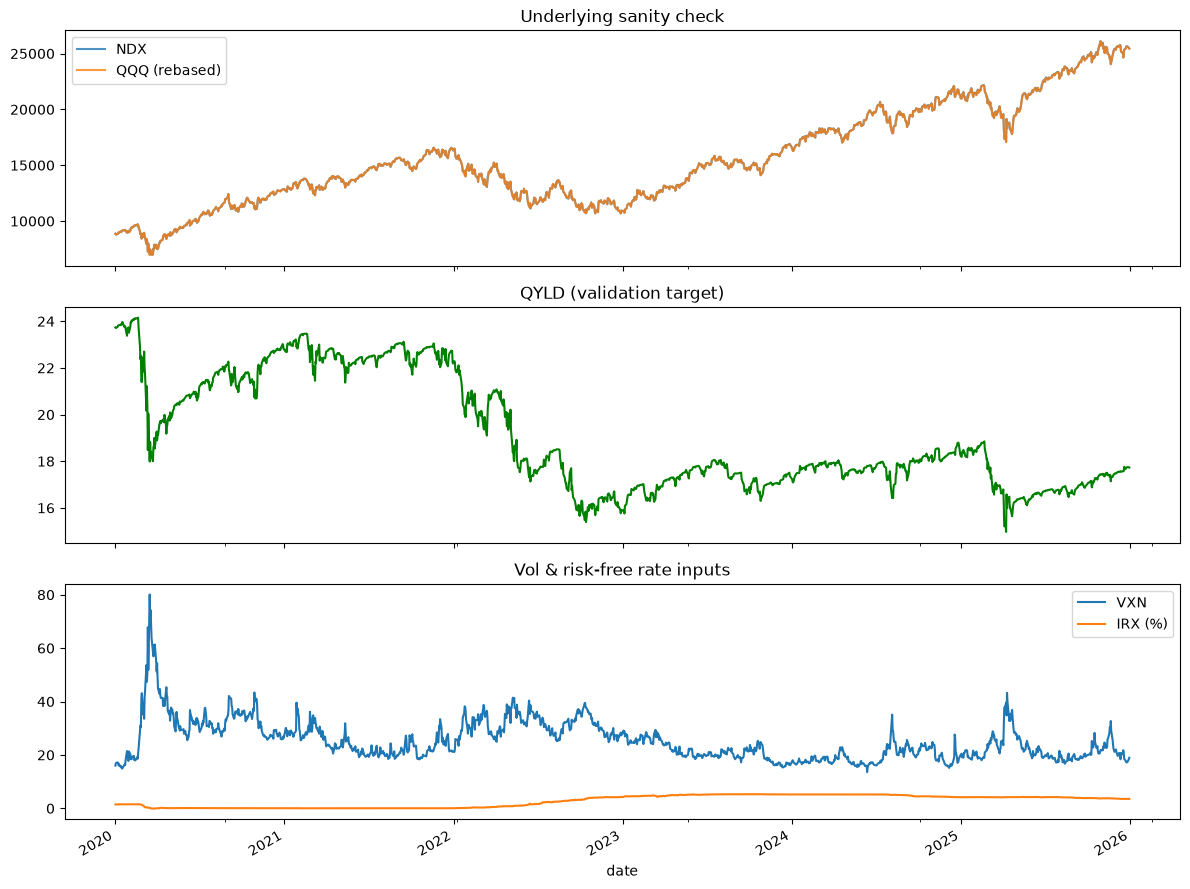

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Summary table
summary = pd.DataFrame({
    ticker: {
        "rows": len(df),
        "start": df.index.min().date(),
        "end": df.index.max().date(),
        "missing": int(df.isna().sum().sum()),
        "close_min": df["Close"].min(),
        "close_max": df["Close"].max(),
        "close_last": df["Close"].iloc[-1],
    }
    for ticker, df in data.items()
}).T

display(summary)

# Date alignment across tickers
date_sets = {t: set(df.index) for t, df in data.items()}
common = set.intersection(*date_sets.values())
print(f"Common trading dates: {len(common)} / {len(next(iter(date_sets.values())))}")
for t, dates in date_sets.items():
    if dates != common:
        print(f"  {t}: {len(dates - common)} extra, {len(common - dates)} missing vs common set")

# Project-specific sanity checks
ndx, qqq = data["^NDX"]["Close"], data["QQQ"]["Close"]
daily_corr = ndx.pct_change().corr(qqq.pct_change())
print(f"\nNDX vs QQQ daily return corr: {daily_corr:.3f}  (expect ~0.99+)")

qyld = data["QYLD"]
print(f"QYLD Close/Adj Close ratio (last): {(qyld['Close'] / qyld['Adj Close']).iloc[-1]:.2f}")
print("  → should drift over time if auto_adjust=False (dividends)")

print(f"^VXN range: {data['^VXN']['Close'].min():.1f} – {data['^VXN']['Close'].max():.1f}")
print(f"^IRX range: {data['^IRX']['Close'].min():.2f}% – {data['^IRX']['Close'].max():.2f}%")

# Quick visual
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

data["^NDX"]["Close"].plot(ax=axes[0], label="NDX", alpha=0.8)
(data["QQQ"]["Close"] / data["QQQ"]["Close"].iloc[0] * data["^NDX"]["Close"].iloc[0]).plot(
    ax=axes[0], label="QQQ (rebased)", alpha=0.8
)
axes[0].set_title("Underlying sanity check")
axes[0].legend()

data["QYLD"]["Close"].plot(ax=axes[1], color="green")
axes[1].set_title("QYLD (validation target)")

data["^VXN"]["Close"].plot(ax=axes[2], label="VXN")
data["^IRX"]["Close"].plot(ax=axes[2], label="IRX (%)")
axes[2].set_title("Vol & risk-free rate inputs")
axes[2].legend()

plt.tight_layout()
plt.show()